In [1]:
import os
import json
import numpy as np
from scipy.interpolate import make_interp_spline

# ---------- 設定 ----------
INPUT_JSON = "./test.json"
OUTPUT_JSON = "./test_spline_smoothed.json"

# ---------- データ読み込み ----------
with open(INPUT_JSON, encoding="utf-8") as f:
    all_data = json.load(f)

smoothed_data = {}

# ---------- 各シーンを処理 ----------
for scene_id, frame_dict in all_data.items():
    frame_keys = sorted(frame_dict.keys())
    x = np.array([int(k.replace("frame_", "")) for k in frame_keys])
    y = np.array([frame_dict[k] for k in frame_keys])

    # スプライン補間 → 元のフレーム数に再サンプリング
    if len(x) >= 4:
        x_dense = np.linspace(x.min(), x.max(), len(x) * 5)
        spline = make_interp_spline(x, y, k=3)
        y_dense = spline(x_dense)
        y_resampled = np.interp(x, x_dense, y_dense)
    else:
        y_resampled = y  # 点が少なすぎる場合はそのまま

    # 保存形式に変換（丸めなし）
    smoothed_data[scene_id] = {
        frame_keys[i]: float(y_resampled[i]) for i in range(len(frame_keys))
    }

# ---------- 新しいJSONに保存 ----------
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(smoothed_data, f, ensure_ascii=False, indent=2)

print("✅ 丸めなしで test_spline_smoothed.json に保存しました。")


✅ 丸めなしで test_spline_smoothed.json に保存しました。


In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------- 設定 ----------
ORIGINAL_JSON = "./testdistance_estimates.json"
SMOOTHED_JSON = "./test_spline_smoothed_fixed.json"
GRAPH_DIR = "./comparison_graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

# ---------- JSON読み込み ----------
with open(ORIGINAL_JSON, encoding="utf-8") as f:
    original_data = json.load(f)

with open(SMOOTHED_JSON, encoding="utf-8") as f:
    smoothed_data = json.load(f)

# ---------- 比較グラフ描画 ----------
for scene_id in original_data:
    if scene_id not in smoothed_data:
        continue

    # 共通のフレームを取得（順序保証）
    orig_frames = sorted(original_data[scene_id].keys())
    smooth_frames = sorted(smoothed_data[scene_id].keys())
    common_frames = sorted(set(orig_frames) & set(smooth_frames))
    if len(common_frames) < 2:
        continue

    x = np.array([int(f.replace("frame_", "")) for f in common_frames])
    y_orig = np.array([original_data[scene_id][f] for f in common_frames])
    y_smooth = np.array([smoothed_data[scene_id][f] for f in common_frames])

    # 描画
    plt.figure(figsize=(10, 6))
    plt.plot(x, y_orig, 'o-', color='gray', label='Original')
    plt.plot(x, y_smooth, 'o-', color='green', label='Spline Smoothed')
    plt.title(f"Scene {scene_id} - Distance Comparison")
    plt.xlabel("Frame Index")
    plt.ylabel("Distance (m)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, f"scene{scene_id}.png"))
    plt.close()

print("✅ 比較グラフを ./comparison_graphs に保存しました。")


✅ 比較グラフを ./comparison_graphs に保存しました。


✔️ frame_51〜frame_96 を線形補間で修正


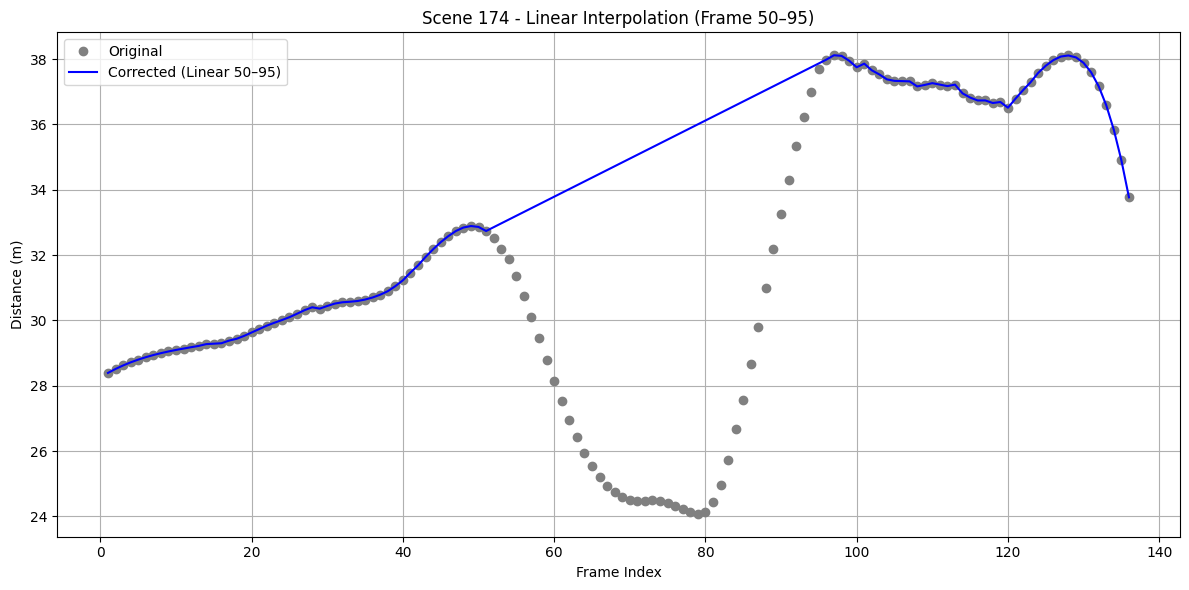

✅ 修正済みグラフを保存しました: scene174_linear_fixed_50_95.png


In [19]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------- 設定 ----------
json_path = "./test_spline_smoothed.json"
scene_id = "174"
output_image_path = f"scene{scene_id}_linear_fixed_50_95.png"

# ---------- JSON読み込み ----------
with open(json_path, encoding="utf-8") as f:
    data = json.load(f)

frame_dict = data[scene_id]
frame_keys = sorted(frame_dict.keys(), key=lambda k: int(k.replace("frame_", "")))
x = np.array([int(k.replace("frame_", "")) for k in frame_keys])
y = np.array([frame_dict[k] for k in frame_keys])
y_corrected = y.copy()

# ---------- 直線補間する区間 ----------
start_idx = 50
end_idx = 95

# 値の取得
y_start = y_corrected[start_idx]
y_end = y_corrected[end_idx]

# 線形補間実行
interp_vals = np.linspace(y_start, y_end, end_idx - start_idx + 1)
y_corrected[start_idx:end_idx + 1] = interp_vals

print(f"✔️ frame_{x[start_idx]}〜frame_{x[end_idx]} を線形補間で修正")

# ---------- グラフ描画 ----------
plt.figure(figsize=(12, 6))
plt.plot(x, y, 'o', color='gray', label='Original')
plt.plot(x, y_corrected, '-', color='blue', label='Corrected (Linear 50–95)')
plt.title(f"Scene {scene_id} - Linear Interpolation (Frame 50–95)")
plt.xlabel("Frame Index")
plt.ylabel("Distance (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_image_path)
plt.show()

print(f"✅ 修正済みグラフを保存しました: {output_image_path}")


✔️ frame_51〜frame_96 を線形補間で修正


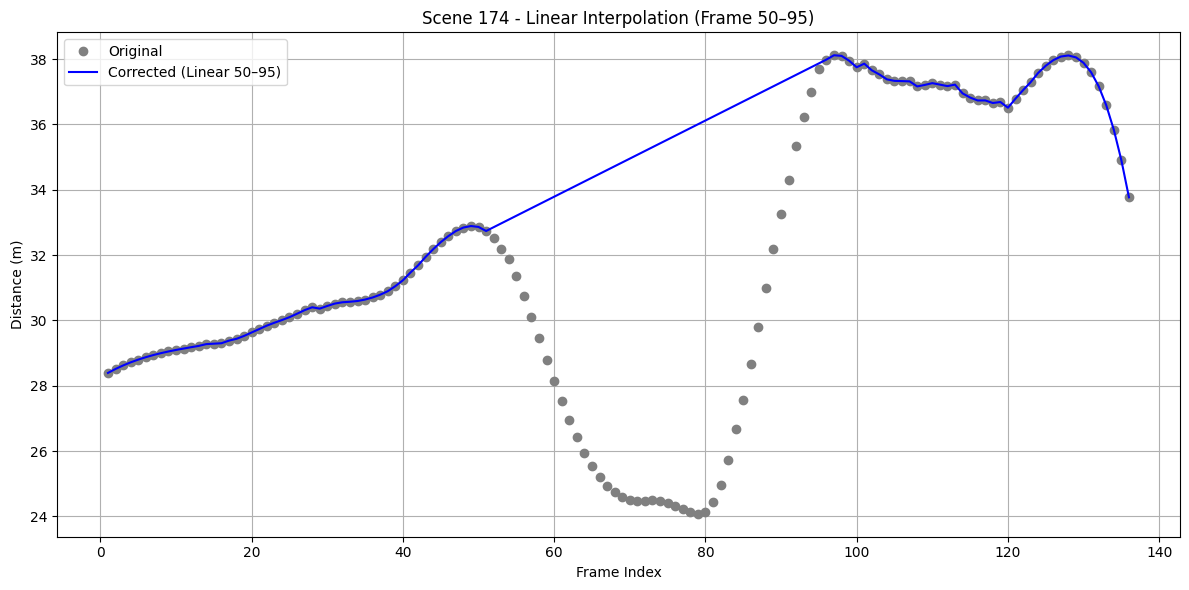

✅ グラフを保存しました: scene174_linear_fixed_50_95.png


In [20]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------- 設定 ----------
json_path = "./test_spline_smoothed.json"
scene_id = "174"
output_image_path = f"scene{scene_id}_linear_fixed_50_95.png"

# ---------- JSON読み込み ----------
with open(json_path, encoding="utf-8") as f:
    data = json.load(f)

frame_dict = data[scene_id]
frame_keys = sorted(frame_dict.keys(), key=lambda k: int(k.replace("frame_", "")))
x = [int(k.replace("frame_", "")) for k in frame_keys]
y = [frame_dict[f"frame_{str(i).zfill(5)}"] for i in x]
y = np.array(y)
y_corrected = y.copy()

# ---------- 直線補間の範囲 ----------
start_idx = 50
end_idx = 95

# 補間値を生成
y_start = y_corrected[start_idx]
y_end = y_corrected[end_idx]
interp_vals = np.linspace(y_start, y_end, end_idx - start_idx + 1)

# 値を上書き
y_corrected[start_idx:end_idx + 1] = interp_vals

print(f"✔️ frame_{x[start_idx]}〜frame_{x[end_idx]} を線形補間で修正")

# ---------- グラフ描画 ----------
plt.figure(figsize=(12, 6))
plt.plot(x, y, 'o', color='gray', label='Original')
plt.plot(x, y_corrected, '-', color='blue', label='Corrected (Linear 50–95)')
plt.title(f"Scene {scene_id} - Linear Interpolation (Frame 50–95)")
plt.xlabel("Frame Index")
plt.ylabel("Distance (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_image_path)
plt.show()

print(f"✅ グラフを保存しました: {output_image_path}")


✅ 修正済みJSONを書き出しました: scene174_linear_fixed.json


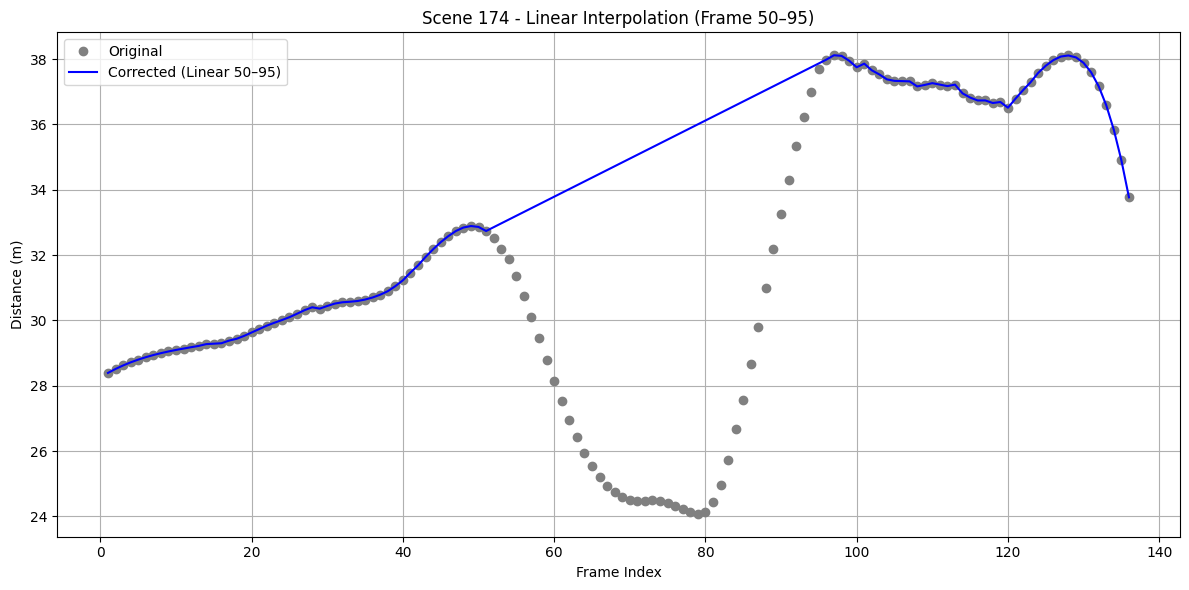

✅ グラフを保存しました: scene174_linear_fixed_50_95.png


In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------- 設定 ----------
json_path = "./test_spline_smoothed.json"
scene_id = "174"
output_image_path = f"scene{scene_id}_linear_fixed_50_95.png"
output_json_path = f"scene{scene_id}_linear_fixed.json"

# ---------- JSON読み込み ----------
with open(json_path, encoding="utf-8") as f:
    data = json.load(f)

frame_dict = data[scene_id]
frame_keys = sorted(frame_dict.keys(), key=lambda k: int(k.replace("frame_", "")))
x = [int(k.replace("frame_", "")) for k in frame_keys]
y = [frame_dict[f"frame_{str(i).zfill(5)}"] for i in x]
y = np.array(y)
y_corrected = y.copy()

# ---------- 直線補間の範囲 ----------
start_idx = 50
end_idx = 95

# 補間値を生成
y_start = y_corrected[start_idx]
y_end = y_corrected[end_idx]
interp_vals = np.linspace(y_start, y_end, end_idx - start_idx + 1)

# 置き換え
y_corrected[start_idx:end_idx + 1] = interp_vals

# ---------- frame_00000形式で辞書に変換 ----------
corrected_dict = {}
for i, val in zip(x, y_corrected):
    key = f"frame_{str(i).zfill(5)}"
    corrected_dict[key] = float(round(val, 4))  # floatでJSON互換に

# ---------- JSON保存 ----------
with open(output_json_path, "w", encoding="utf-8") as f:
    json.dump({scene_id: corrected_dict}, f, indent=2, ensure_ascii=False)

print(f"✅ 修正済みJSONを書き出しました: {output_json_path}")

# ---------- グラフ描画 ----------
plt.figure(figsize=(12, 6))
plt.plot(x, y, 'o', color='gray', label='Original')
plt.plot(x, y_corrected, '-', color='blue', label='Corrected (Linear 50–95)')
plt.title(f"Scene {scene_id} - Linear Interpolation (Frame 50–95)")
plt.xlabel("Frame Index")
plt.ylabel("Distance (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_image_path)
plt.show()

print(f"✅ グラフを保存しました: {output_image_path}")


✅ 補正済みの JSON を保存しました: ./test_splinne_smoothed_fixed.json


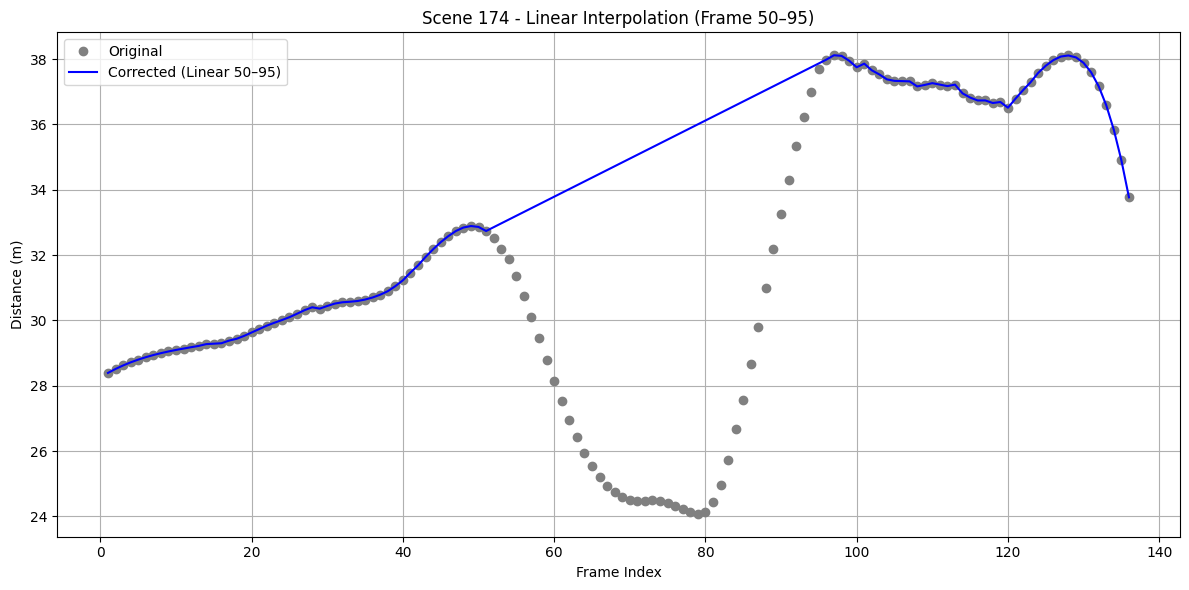

✅ グラフを保存しました: scene174_linear_fixed_50_95.png


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------- 設定 ----------
input_json_path = "./test_spline_smoothed.json"
scene_id = "174"
output_json_path = "./test_splinne_smoothed_fixed.json"
output_image_path = f"scene{scene_id}_linear_fixed_50_95.png"

# ---------- JSON読み込み ----------
with open(input_json_path, encoding="utf-8") as f:
    data = json.load(f)

frame_dict = data[scene_id]
frame_keys = sorted(frame_dict.keys(), key=lambda k: int(k.replace("frame_", "")))
x = [int(k.replace("frame_", "")) for k in frame_keys]
y = [frame_dict[f"frame_{str(i).zfill(5)}"] for i in x]
y = np.array(y)
y_corrected = y.copy()

# ---------- 補間範囲 ----------
start_idx = 50
end_idx = 95
y_start = y_corrected[start_idx]
y_end = y_corrected[end_idx]
interp_vals = np.linspace(y_start, y_end, end_idx - start_idx + 1)
y_corrected[start_idx:end_idx + 1] = interp_vals

# ---------- 上書きされた scene174 を作成 ----------
updated_frame_dict = {}
for i, val in zip(x, y_corrected):
    key = f"frame_{str(i).zfill(5)}"
    updated_frame_dict[key] = float(round(val, 4))

# ---------- 元のデータに上書き ----------
data[scene_id] = updated_frame_dict

# ---------- 新しいJSONに保存 ----------
with open(output_json_path, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print(f"✅ 補正済みの JSON を保存しました: {output_json_path}")

# ---------- グラフ描画 ----------
plt.figure(figsize=(12, 6))
plt.plot(x, y, 'o', color='gray', label='Original')
plt.plot(x, y_corrected, '-', color='blue', label='Corrected (Linear 50–95)')
plt.title(f"Scene {scene_id} - Linear Interpolation (Frame 50–95)")
plt.xlabel("Frame Index")
plt.ylabel("Distance (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_image_path)
plt.show()

print(f"✅ グラフを保存しました: {output_image_path}")
